# Project: 멋진 챗봇 만들기


In [1]:
# 필요한 라이브러리 설치 (Colab)
!pip install -q konlpy python-mecab-ko   # konlpy: 형태소 분석 / python-mecab-ko: mecab 대체 패키지

try:
    import gensim                        # 단어 임베딩(Word2Vec) 라이브러리
except ImportError:
    !pip install -q gensim               # 없으면 설치

# KoNLPy의 Mecab 클래스를 직접 쓰려면 아래 주석을 해제하세요 (3~5분 소요)
# !curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh | bash

print("설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.3 MB/s eta 0:00:00
설치 완료


In [2]:
import numpy as np                                    # 수치 계산
import pandas as pd                                   # CSV 데이터 처리
import torch                                          # PyTorch 딥러닝 프레임워크
import torch.nn as nn                                 # 신경망 레이어 모듈
import torch.nn.functional as F                       # softmax, cross_entropy 등 함수형 API
from nltk.translate.bleu_score import sentence_bleu   # BLEU 점수 계산
from nltk.translate.bleu_score import SmoothingFunction  # BLEU 0점 방지 스무딩

import re              # 정규표현식 (텍스트 정제)
import os              # 파일 경로/존재 확인
import random          # 무작위 선택 (augmentation)
import math            # sqrt 등 수학 함수
import zipfile         # zip 압축 해제
import urllib.request  # 파일 다운로드
from collections import Counter  # 단어 빈도 집계 (단어 사전 구축)

from tqdm.notebook import tqdm       # 진행 상황 프로그레스 바
import matplotlib.pyplot as plt      # 손실 그래프 시각화

# 재현성을 위한 시드 고정 (매번 같은 결과가 나오도록)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 cuda, 없으면 cpu 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print("Device:", device)

2.11.0+cu128
Device: cuda


## Step 1. 데이터 다운로드


In [3]:
csv_filename = "ChatbotData.csv"   # 저장할 파일명
csv_url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"  # 데이터 원본 주소

# 파일이 없을 때만 다운로드 (재실행 시 중복 다운로드 방지)
if not os.path.exists(csv_filename):
    urllib.request.urlretrieve(csv_url, csv_filename)

data = pd.read_csv(csv_filename)   # CSV를 DataFrame으로 읽기 (컬럼: Q, A, label)
questions = list(data["Q"])        # 질문 컬럼 → 리스트
answers = list(data["A"])          # 답변 컬럼 → 리스트

print("전체 데이터 쌍:", len(questions))
data.head()   # 데이터 형태 확인

전체 데이터 쌍: 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## Step 2. 데이터 정제


In [4]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()   # 조건 1: 대문자를 소문자로 변환
    # 조건 2: 영문자, 한글(완성형 가-힣 + 자모 ㄱ-ㅎ,ㅏ-ㅣ), 숫자, 주요 특수문자(?.!,) 외에는 공백으로 치환
    sentence = re.sub(r"[^a-z0-9가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)
    sentence = re.sub(r" {2,}", " ", sentence)   # 둘 이상의 연속 공백을 하나로
    sentence = sentence.strip()                  # 문자열 양 끝 공백 제거
    return sentence

# 동작 확인: 특수문자(@, ~)는 제거되고 소문자로 변환되는지 확인
print(preprocess_sentence("12시   땡! @@ Hello~~"))

12시 땡! hello


## Step 3. 데이터 토큰화


In [5]:
# 형태소 분석기 준비: KoNLPy Mecab 우선, 실패 시 python-mecab-ko로 대체
try:
    from konlpy.tag import Mecab
    mecab = Mecab()                  # mecab 미설치 환경이면 여기서 예외 발생
    print("KoNLPy Mecab 사용")
except Exception:
    from mecab import MeCab          # python-mecab-ko (pip만으로 설치 가능)
    mecab = MeCab()
    print("python-mecab-ko 사용 (KoNLPy Mecab과 동일한 morphs API)")

# 형태소 단위로 잘 쪼개지는지 확인
print(mecab.morphs("아버지가방에들어가신다"))

python-mecab-ko 사용 (KoNLPy Mecab과 동일한 morphs API)
['아버지', '가', '방', '에', '들어가', '신다']


In [6]:
def build_corpus(src_data, tgt_data, tokenize_fn, max_token_len=20):
    src_corpus = []      # 토큰화된 소스(질문) 저장
    tgt_corpus = []      # 토큰화된 타겟(답변) 저장
    seen_src = set()     # 소스 중복 검사용 집합
    seen_tgt = set()     # 타겟 중복 검사용 집합

    # 질문-답변을 쌍으로 묶어 순회 (쌍이 흐트러지지 않도록 zip 사용)
    for src, tgt in tqdm(zip(src_data, tgt_data), total=len(src_data)):
        # 조건 2: 정제
        src = preprocess_sentence(str(src))
        tgt = preprocess_sentence(str(tgt))

        # 조건 3: 전달받은 토크나이즈 함수로 토큰화 (mecab.morphs)
        src_tokens = tokenize_fn(src)
        tgt_tokens = tokenize_fn(tgt)

        # 조건 4: 토큰 수가 일정 길이 이상인 문장은 쌍째로 제외
        if len(src_tokens) > max_token_len or len(tgt_tokens) > max_token_len:
            continue
        if len(src_tokens) == 0 or len(tgt_tokens) == 0:   # 빈 문장도 제외
            continue

        # 조건 5: 중복 제거 — 소스는 소스대로, 타겟은 타겟대로 검사
        src_key = " ".join(src_tokens)   # 토큰 리스트를 문자열로 만들어 집합에 저장
        tgt_key = " ".join(tgt_tokens)
        if src_key in seen_src or tgt_key in seen_tgt:
            continue                     # 둘 중 하나라도 중복이면 쌍째로 제외 (쌍 유지)
        seen_src.add(src_key)
        seen_tgt.add(tgt_key)

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus


# 질문/답변 데이터에 적용
que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_token_len=20)

print("정제/토큰화 후 데이터 쌍:", len(que_corpus))
print("질문 예시:", que_corpus[0])
print("답변 예시:", ans_corpus[0])

  0%|          | 0/11823 [00:00<?, ?it/s]

정제/토큰화 후 데이터 쌍: 7573
질문 예시: ['12', '시', '땡', '!']
답변 예시: ['하루', '가', '또', '가', '네요', '.']


In [7]:
# 성능 측정(Step 7)용 평가 데이터를 미리 분리합니다.
# Augmentation 전에 분리해야 평가 데이터가 학습에 새어 들어가지 않습니다(데이터 누수 방지).
test_size = 100

test_que = que_corpus[-test_size:]    # 마지막 100쌍 → 평가용
test_ans = ans_corpus[-test_size:]
que_corpus = que_corpus[:-test_size]  # 나머지 → 학습용
ans_corpus = ans_corpus[:-test_size]

print("학습용:", len(que_corpus), " / 평가용:", len(test_que))

학습용: 7473  / 평가용: 100


## Step 4. Augmentation (Lexical Substitution)


In [8]:
wv_ko = None   # 최종적으로 사용할 단어 벡터 (KeyedVectors)

# --- 방법 1: Kyubyong/wordvectors 의 ko.bin (Korean (w), Word2Vec) ---
if not os.path.exists("ko.bin"):
    try:
        import gdown   # 구글 드라이브 파일 다운로드 도구
        gdown.download(id="0B0ZXk88koS2KbDhXdWg1Q2RydlU", output="ko.zip", quiet=False)
        with zipfile.ZipFile("ko.zip") as z:
            z.extractall(".")               # 압축 해제 → ko.bin 생성
    except Exception as e:
        print("ko.bin 자동 다운로드 실패:", e)
        print("-> https://github.com/Kyubyong/wordvectors 에서 Korean (w)를 받아 ko.bin을 업로드하면 사용됩니다.")

if os.path.exists("ko.bin"):
    try:
        from gensim.models import Word2Vec
        wv_ko = Word2Vec.load("ko.bin").wv   # 학습된 모델에서 단어 벡터만 추출
        print("ko.bin 로드 완료 / 어휘 수:", len(wv_ko.key_to_index))
    except Exception as e:
        print("ko.bin 로드 실패 (gensim 버전 호환 문제일 수 있음):", e)

# --- 방법 2 (fallback): 챗봇 말뭉치로 Word2Vec 직접 학습 ---
if wv_ko is None:
    from gensim.models import Word2Vec
    print("대체 방법: 챗봇 말뭉치로 Word2Vec을 직접 학습합니다.")
    w2v_model = Word2Vec(sentences=que_corpus + ans_corpus,  # 질문+답변 전체를 학습 데이터로
                         vector_size=100,   # 단어 벡터 차원
                         window=5,          # 앞뒤 5단어까지 문맥으로 사용
                         min_count=2,       # 2번 이상 등장한 단어만 학습
                         epochs=30,         # 반복 횟수
                         seed=SEED)
    wv_ko = w2v_model.wv
    print("학습 완료 / 어휘 수:", len(wv_ko.key_to_index))

# 동작 확인: 첫 답변의 첫 단어와 유사한 단어 조회
sample_word = ans_corpus[0][0]
if sample_word in wv_ko:
    print(sample_word, "->", wv_ko.most_similar(sample_word)[:3])

Downloading...
From (original): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU
From (redirected): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU&confirm=t&uuid=4cfe3d25-d08c-403b-b3b7-1035f729ee2e
To: /content/ko.zip
100%|██████████| 80.6M/80.6M [00:01<00:00, 55.4MB/s]
ERROR:gensim.models.word2vec:Model load error. Was model saved using code from an older Gensim Version? Try loading older model using gensim-3.8.3, then re-saving, to restore compatibility with current code.


ko.bin 로드 실패 (gensim 버전 호환 문제일 수 있음): 'Word2Vec' object has no attribute 'wv'
대체 방법: 챗봇 말뭉치로 Word2Vec을 직접 학습합니다.
학습 완료 / 어휘 수: 3488
하루 -> [('달째', 0.6899566054344177), ('주말', 0.6745594143867493), ('박', 0.6657102704048157)]


In [9]:
def lexical_sub(tokens, wv):
    """토큰 리스트에서 임베딩에 존재하는 단어 하나를 골라
    가장 유사한 단어로 치환한 새 토큰 리스트를 반환. 실패 시 None."""
    # 임베딩 어휘에 존재하는 단어만 치환 후보로 선정 (KeyError 방지)
    valid_tokens = [tok for tok in tokens if tok in wv]
    if not valid_tokens:
        return None   # 치환 가능한 단어가 하나도 없으면 실패

    selected_tok = random.choice(valid_tokens)          # 무작위로 한 단어 선택
    similar_word = wv.most_similar(selected_tok)[0][0]  # 코사인 유사도 1위 단어

    # 선택된 단어를 유사 단어로 교체 (같은 단어가 여러 번 나오면 모두 교체됨)
    new_tokens = [similar_word if tok == selected_tok else tok for tok in tokens]
    if new_tokens == list(tokens):
        return None   # 치환 결과가 원본과 같으면 증강 의미가 없으므로 제외
    return new_tokens


# 동작 확인: 원본과 치환 결과 비교
print("원본:", que_corpus[0])
print("치환:", lexical_sub(que_corpus[0], wv_ko))

원본: ['12', '시', '땡', '!']
치환: ['9', '시', '땡', '!']


In [10]:
aug_que = []   # 증강 후 전체 질문
aug_ans = []   # 증강 후 전체 답변

# 1) 원본 쌍 (list()로 복사해 원본 훼손 방지)
aug_que += [list(q) for q in que_corpus]
aug_ans += [list(a) for a in ans_corpus]

# 2) Augmentation된 질문 + 원본 답변 (병렬 유지)
for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    new_q = lexical_sub(q, wv_ko)     # 질문만 치환
    if new_q is not None:             # 치환 성공한 쌍만 추가
        aug_que.append(new_q)
        aug_ans.append(list(a))

# 3) 원본 질문 + Augmentation된 답변 (병렬 유지)
for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    new_a = lexical_sub(a, wv_ko)     # 답변만 치환
    if new_a is not None:
        aug_que.append(list(q))
        aug_ans.append(new_a)

print("원본 데이터 쌍:", len(que_corpus))
print("Augmentation 후 데이터 쌍:", len(aug_que), "(약 %.1f배)" % (len(aug_que) / len(que_corpus)))

  0%|          | 0/7473 [00:00<?, ?it/s]

  0%|          | 0/7473 [00:00<?, ?it/s]

원본 데이터 쌍: 7473
Augmentation 후 데이터 쌍: 22393 (약 3.0배)


## Step 5. 데이터 벡터화


In [11]:
# 리스트 덧셈으로 특수 토큰을 쉽게 추가할 수 있습니다
sample_data = ["12", "시", "땡", "!"]

print(["<start>"] + sample_data + ["<end>"])

# 타겟 데이터 전체에 <start>, <end> 토큰 추가
# (디코더가 문장의 시작과 끝을 알 수 있게 함)
ans_corpus_final = [["<start>"] + a + ["<end>"] for a in aug_ans]
que_corpus_final = aug_que   # 소스(질문)에는 추가하지 않음

print(ans_corpus_final[0])

['<start>', '12', '시', '땡', '!', '<end>']
['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']


In [12]:
# 전체 데이터(질문+답변)에 대한 단어 사전 구축
counter = Counter()                                  # 단어별 등장 횟수 집계기
for tokens in que_corpus_final + ans_corpus_final:   # 질문+답변을 합쳐 하나의 사전으로
    counter.update(tokens)

# 특수 토큰을 고정 ID로 먼저 등록 (<pad>=0 은 마스크/손실 계산과 일치해야 함)
vocab = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
for word, freq in counter.most_common():   # 빈도 높은 단어부터 ID 부여
    if word not in vocab:                  # <start>/<end>는 이미 등록됐으므로 건너뜀
        vocab[word] = len(vocab)

idx2word = {idx: word for word, idx in vocab.items()}   # ID → 단어 역방향 사전 (디코딩용)
VOCAB_SIZE = len(vocab)
print("단어 사전 크기:", VOCAB_SIZE)

단어 사전 크기: 6179


In [13]:
MAX_LEN = 25   # 최대 시퀀스 길이 (토큰 20 + <start>/<end> 여유분)


def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        if len(seq) > max_len:
            seq = seq[:max_len]                              # 초과 길이는 자르고
        else:
            seq = seq + [pad_value] * (max_len - len(seq))   # 부족한 길이는 0으로 채움
        padded_sequences.append(seq)

    # 임베딩 인덱스로 쓰이므로 long(정수) 타입 텐서로 변환
    return torch.tensor(padded_sequences, dtype=torch.long)


def tokens_to_ids(tokens):
    # 사전에 없는 단어는 <unk>(3)로 대체
    return [vocab.get(tok, vocab["<unk>"]) for tok in tokens]


# 토큰 → ID 변환 후 패딩하여 학습용 텐서 생성
enc_train = pad_sequences_custom([tokens_to_ids(t) for t in que_corpus_final], max_len=MAX_LEN)  # 인코더 입력(질문)
dec_train = pad_sequences_custom([tokens_to_ids(t) for t in ans_corpus_final], max_len=MAX_LEN)  # 디코더 입력(답변)

print("enc_train:", enc_train.shape)   # [데이터 수, 25]
print("dec_train:", dec_train.shape)

enc_train: torch.Size([22393, 25])
dec_train: torch.Size([22393, 25])


In [14]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
# 질문 텐서와 답변 텐서를 묶어 하나의 데이터셋으로 (같은 인덱스 = 질문-답변 쌍)
train_dataset = TensorDataset(enc_train, dec_train)
# shuffle: 매 에폭마다 순서 섞기 / pin_memory: CPU→GPU 전송 속도 향상
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

print("배치 수:", len(train_dataloader))

배치 수: 350


## Step 6. 훈련하기


In [15]:
# Positional Encoding 구현 ("Attention Is All You Need"의 사인파 방식)
# Transformer는 단어를 동시에 처리하므로 "몇 번째 단어인지" 정보를 벡터로 만들어 더해줌
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        # 위치와 차원 인덱스로 각도 계산: pos / 10000^(2i/d_model)
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        # 한 위치에 대한 d_model개의 각도 벡터
        return [cal_angle(position, i) for i in range(d_model)]

    # 모든 위치 x 모든 차원의 각도 표 생성: [pos, d_model]
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])   # 짝수 차원에는 사인
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])   # 홀수 차원에는 코사인

    return sinusoid_table

In [16]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """(seq == 0)인 위치가 1인 [batch, 1, 1, seq_len] 패딩 마스크
    → 의미 없는 <pad> 위치를 어텐션이 무시하도록 함"""
    # unsqueeze 2번: 멀티헤드 어텐션 점수 [batch, heads, len, len]와 브로드캐스팅 되도록 차원 확장
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """미래 토큰(대각선 위)이 1인 [size, size] 룩어헤드 마스크
    → 디코더가 자기 이전 단어만 보도록 미래를 차단 (컨닝 방지)"""
    # triu(diagonal=1): 주대각선 위쪽만 1인 상삼각 행렬
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    # 1) 인코더 자기어텐션용: 소스(질문)의 패딩만 가림
    enc_mask = generate_padding_mask(src)
    # 2) 디코더-인코더(크로스) 어텐션용: 역시 소스의 패딩을 가림
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션용: 룩어헤드 + 타겟 패딩 마스크를 합침
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])   # [tgt_len, tgt_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)            # [batch, 1, 1, tgt_len]

    # 배치/헤드 차원과 맞도록 확장: [1, 1, tgt_len, tgt_len]
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    # max로 병합: 둘 중 하나라도 1이면 1 → "패딩이거나 미래인 위치"를 모두 가림
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

In [17]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads   # 각 헤드가 담당할 차원 수 (368/8=46)

        # Query, Key, Value를 만드는 선형 변환
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        # 헤드들의 출력을 결합한 뒤 통과시키는 최종 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))   # 모든 단어 쌍의 유사도 점수 [.., len, len]

        # sqrt(d_k)로 나눠 스케일링 (softmax가 극단적으로 치우치는 것 방지)
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            # 마스크가 1인 위치(패딩/미래)에 -10억을 더해 softmax 후 확률이 0에 수렴하게 함
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)   # 유사도를 확률로 변환
        out = torch.matmul(attentions, V)           # 확률 비율대로 V를 가중합

        return out, attentions

    def split_heads(self, x):
        # [batch, len, d_model] → [batch, heads, len, depth]로 재배치
        # d_model 벡터를 heads개 조각으로 나눠 각 헤드가 독립적으로 어텐션하게 함
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        # split_heads의 역연산: [batch, heads, len, depth] → [batch, len, d_model]
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # 1) 선형 변환으로 Q, K, V 생성
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # 2) 멀티헤드로 분할
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # 3) 각 헤드에서 독립적으로 어텐션 수행
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # 4) 헤드 결합 후 최종 선형 변환
        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

In [18]:
class PoswiseFeedForwardNet(nn.Module):
    """위치별 피드포워드: 어텐션으로 모인 정보를 각 단어 위치에서 개별 가공
    구조: d_model → d_ff(확장) → ReLU → d_model(압축)"""
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)   # 차원 확장 (368 → 1024)
        self.fc2 = nn.Linear(d_ff, d_model)   # 다시 원래 차원으로 압축
        self.relu = nn.ReLU()                 # 비선형성 추가

    def forward(self, x):
        out = self.relu(self.fc1(x))   # 확장 + 활성화
        out = self.fc2(out)            # 압축
        return out

In [19]:
class EncoderLayer(nn.Module):
    """인코더 레이어 = 자기어텐션 블록 + FFN 블록
    각 블록: LayerNorm → 연산 → Dropout → 잔차 연결 (Pre-LN 방식)"""
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)   # 자기어텐션
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)             # 피드포워드

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)   # 어텐션 앞 정규화
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)   # FFN 앞 정규화

        self.do = nn.Dropout(dropout)   # 과적합 방지

    def forward(self, x, mask):
        # --- 자기어텐션 블록 ---
        residual = x                # 잔차 연결용 입력 보관
        out = self.norm_1(x)
        # Q=K=V 모두 같은 입력 → "자기"어텐션 (문장 내 단어끼리 문맥 교환)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual        # 잔차 연결: 기울기 흐름 안정화

        # --- FFN 블록 ---
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, enc_attn


class DecoderLayer(nn.Module):
    """디코더 레이어 = 마스크드 자기어텐션 + 크로스 어텐션 + FFN (블록 3개)"""
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)   # 마스크드 자기어텐션
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)    # 인코더-디코더 크로스 어텐션
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # --- 1. 마스크드 자기어텐션: 생성 중인 답변끼리, 미래 토큰은 차단 ---
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # --- 2. 크로스 어텐션: Q는 디코더, K/V는 인코더 출력 ---
        # "지금 생성하려는 답변 단어가 질문의 어느 단어를 참고해야 하는가"
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # --- 3. FFN ---
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

In [20]:
class Encoder(nn.Module):
    """EncoderLayer를 n_layers개 쌓은 인코더 전체"""
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        # ModuleList: 파라미터가 모델에 등록되도록 (일반 리스트면 학습에서 누락됨)
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # Pre-LN 표준: 스택 마지막 출력 정규화용 LayerNorm
        # (없으면 잔차 누적으로 출력 norm이 커져 어텐션 포화/모드 붕괴 위험)
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        out = x
        enc_attns = []                     # 시각화용 어텐션 가중치 수집
        for i in range(self.n_layers):     # 레이어를 차례차례 통과
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        out = self.final_norm(out)   # 스택 끝나고 정규화 (Pre-LN 표준)
        return out, enc_attns


class Decoder(nn.Module):
    """DecoderLayer를 n_layers개 쌓은 디코더 전체"""
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # Pre-LN 표준: 스택 마지막 출력 정규화용 LayerNorm
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            # 모든 레이어가 같은 인코더 출력(enc_out)을 참조
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        out = self.final_norm(out)   # 스택 끝나고 정규화 (Pre-LN 표준)
        return out, dec_attns, dec_enc_attns

In [21]:
class Transformer(nn.Module):
    """임베딩 + 위치 인코딩 + 인코더 + 디코더 + 출력층을 조립한 최상위 모델"""
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)   # 임베딩 스케일링에 사용

        # 임베딩: 토큰 ID → d_model 차원 벡터
        if shared_emb:
            # 질문/답변이 같은 언어이므로 인코더-디코더 임베딩 공유 (파라미터 절약)
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # 위치 인코딩: 고정값이므로 파라미터가 아닌 buffer로 등록
        # (학습되지 않지만 model.to(device) 시 함께 이동)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 출력층: 디코더 출력 → 어휘 크기의 점수(logits)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # weight tying: 출력층과 디코더 임베딩의 가중치 공유 (파라미터 절약 + 성능 향상)
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)   # [batch, seq_len, d_model]
        if self.shared_fc:
            # 원논문의 임베딩 스케일링: 위치 인코딩과 값 크기 균형 맞추기
            out = out * math.sqrt(self.d_model)
        # 위치 인코딩을 문장 길이만큼 잘라서 더함
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        # 1) 임베딩 + 위치 인코딩
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # 2) 인코더가 질문을 문맥 표현으로 변환 → 디코더가 참조하며 답변 표현 생성
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        # 3) 각 위치에서 "다음 토큰" 예측 점수 계산: [batch, tgt_len, vocab]
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

In [22]:
# 과적합을 피하기 위한 하이퍼파라미터 (제출용)
# 데이터가 작으므로 번역 모델(2층, d_model 512)보다 작게 설정
N_LAYERS = 1     # 인코더/디코더 층 수
D_MODEL = 368    # 모델 전체 벡터 차원 (368 = 8헤드 x 46차원)
N_HEADS = 8      # 어텐션 헤드 수
D_FF = 1024      # FFN 중간 차원
DROPOUT = 0.2    # 드롭아웃 비율

transformer = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,          # 위치 인코딩 최대 길이 (MAX_LEN=25보다 여유 있게)
    dropout=DROPOUT,
    shared_fc=True,       # 출력층-임베딩 가중치 공유
    shared_emb=True)      # 질문/답변이 같은 언어이므로 임베딩 공유

transformer = transformer.to(device)   # 모델을 GPU로 이동

# 전체 파라미터 수 확인 (공유된 가중치는 한 번만 계산됨)
n_params = sum(p.numel() for p in transformer.parameters())
print("파라미터 수: %.1fM" % (n_params / 1e6))

파라미터 수: 5.4M


In [23]:
class LearningRateScheduler:
    """원논문의 Noam 스케줄러: warmup 동안 선형 증가 → 이후 1/sqrt(step)로 감소"""
    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5                          # 감쇠 구간 (step > warmup일 때 선택됨)
        arg2 = step * (self.warmup_steps ** -1.5)    # 워밍업 구간 (step < warmup일 때 선택됨)
        # d_model이 클수록 전체 학습률을 낮추는 보정
        return (self.d_model ** -0.5) * min(arg1, arg2)


WARMUP_STEPS = 1000   # 학습 초반 1000스텝 동안 학습률을 서서히 올림 (발산 방지)
learning_rate = LearningRateScheduler(D_MODEL, warmup_steps=WARMUP_STEPS)

# Adam 옵티마이저 (betas, eps는 Transformer 원논문 설정)
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),    # 초기값 (매 스텝 갱신됨)
                             betas=(0.9, 0.98),
                             eps=1e-9)

In [24]:
def loss_function(real, pred):
    """real: [batch, seq_len] / pred: [batch, seq_len, vocab] — 패딩(0) 위치는 손실에서 제외"""
    real = real.to(device)
    pred = pred.to(device)

    # [N, C] 형태로 펼쳐서 토큰별 개별 손실 계산 (reduction='none')
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)),
                            real.contiguous().view(-1), reduction="none")
    loss_ = loss_.view(real.size())   # 다시 [batch, seq_len]로 복원

    # 실제 토큰 위치만 1인 마스크 (패딩=0 위치의 손실을 무효화)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 손실 합 / 실제 토큰 수 = 토큰당 평균 손실 (패딩 비율에 왜곡되지 않음)
    return loss_.sum() / mask.sum()


def train_step(src, tgt, model, optimizer):
    model.train()           # 학습 모드 (dropout 활성화)
    optimizer.zero_grad()   # 이전 스텝의 기울기 초기화

    # 타겟 시프트 (teacher forcing):
    # 입력: <start> A B C  /  정답: A B C <end>  → 각 위치에서 "다음 토큰" 맞히기
    tgt_in = tgt[:, :-1]   # 디코더 입력 (마지막 토큰 제외)
    gold = tgt[:, 1:]      # 정답 (첫 토큰 제외)

    # 배치별 마스크 생성
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    # 데이터와 마스크를 GPU로 이동
    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # forward: 예측 logits 계산
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # 패딩 제외 손실 계산
    loss = loss_function(gold, predictions)

    loss.backward()    # 역전파로 기울기 계산
    optimizer.step()   # 파라미터 갱신

    return loss, enc_attns, dec_attns, dec_enc_attns

In [25]:
%%time

EPOCHS = 10   # 전체 데이터 반복 학습 횟수

global_step = 0      # 학습률 스케줄용 전체 스텝 카운터
loss_history = []    # 손실 그래프용 기록

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        # 매 스텝 학습률 스케줄 적용 (warmup 1000 + 감쇠)
        global_step += 1
        lr = learning_rate(global_step)
        for g in optimizer.param_groups:
            g["lr"] = lr

        # 배치 하나 학습
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)

        total_loss += loss.item()          # .item(): 텐서에서 숫자만 추출 (메모리 누적 방지)
        loss_history.append(loss.item())
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}", "LR": f"{lr:.6f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    # 에폭 평균 손실 출력 (꾸준히 감소하면 정상 학습 중)
    print(f"Epoch {epoch+1}, Loss: {total_loss / dataset_count:.4f}")

  0%|          | 0/350 [00:00<?, ?it/s]

Epoch 1, Loss: 127.4240


  0%|          | 0/350 [00:00<?, ?it/s]

Epoch 2, Loss: 12.9438


  0%|          | 0/350 [00:00<?, ?it/s]

...

Epoch 8, Loss: 3.6540


  0%|          | 0/350 [00:00<?, ?it/s]

Epoch 9, Loss: 3.5432


  0%|          | 0/350 [00:00<?, ?it/s]

Epoch 10, Loss: 3.4449
CPU times: user 1min 15s, sys: 1.3 s, total: 1min 16s
Wall time: 1min 22s


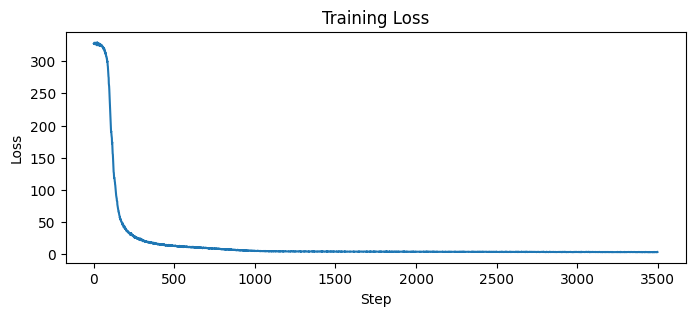

In [26]:
# 학습 손실 곡선 시각화 (감소 추세 확인)
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

### 답변 생성


In [27]:
def generate_answer(sentence, model, max_len=MAX_LEN):
    model.eval()   # 추론 모드 (dropout 비활성화)

    # 질문을 학습 때와 동일하게 전처리 + 토큰화 + ID 변환
    tokens = mecab.morphs(preprocess_sentence(sentence))
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens]

    # 길이를 max_len에 맞춰 자르거나 0으로 패딩
    if len(ids) > max_len:
        ids = ids[:max_len]
    else:
        ids = ids + [0] * (max_len - len(ids))

    src = torch.tensor([ids], dtype=torch.long, device=device)              # 인코더 입력 [1, max_len]
    output = torch.tensor([[vocab["<start>"]]], dtype=torch.long, device=device)  # 디코더 첫 입력: <start>

    result_ids = []
    with torch.no_grad():   # 추론이므로 기울기 계산 생략 (속도/메모리 절약)
        # 자기회귀 생성: 한 번에 한 토큰씩 예측해서 이어 붙임
        for _ in range(max_len):
            # 현재까지의 출력으로 마스크 생성
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, output)

            predictions, _, _, _ = model(src, output,
                                         enc_mask.to(device),
                                         dec_enc_mask.to(device),
                                         dec_mask.to(device))

            # 마지막 위치의 예측에서 확률 최대 토큰 선택 (greedy decoding)
            predicted_id = predictions[0, -1].argmax(dim=-1).item()

            if predicted_id == vocab["<end>"]:   # <end>가 나오면 생성 종료
                break

            result_ids.append(predicted_id)
            # 예측한 토큰을 디코더 입력에 이어 붙여 다음 반복에 사용
            new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
            output = torch.cat([output, new_token], dim=1)

    # 토큰 ID → 단어로 복원해 문장으로 반환
    return " ".join(idx2word.get(i, "<unk>") for i in result_ids)

In [28]:
# 예문에 대한 답변 생성 (제출용)
example_questions = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

# 제출 형식으로 출력
print("Translations")
for i, q in enumerate(example_questions, 1):
    answer = generate_answer(q, transformer)
    print(f"> {i}. {answer} <end>")

print()
# 질문-답변 쌍으로도 확인
for i, q in enumerate(example_questions, 1):
    print(f"Q{i}: {q}")
    print(f"A{i}: {generate_answer(q, transformer)}")
    print()

Translations
> 1. 좋 은 사람 을 거 예요 . <end>
> 2. 좋 은 시간 이 있 어요 . <end>
> 3. 마음 이 있 어요 . <end>
> 4. 마음 이 죠 . <end>

Q1: 지루하다, 놀러가고 싶어.
A1: 좋 은 사람 을 거 예요 .

Q2: 오늘 일찍 일어났더니 피곤하다.
A2: 좋 은 시간 이 있 어요 .

Q3: 간만에 여자친구랑 데이트 하기로 했어.
A3: 마음 이 있 어요 .

Q4: 집에 있는다는 소리야.
A4: 마음 이 죠 .



## Step 7. 성능 측정하기


In [29]:
def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    # smoothing_function: n-gram 매칭이 0이어도 점수가 0으로 무너지지 않게 보정
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)


total_score = 0.0
results = []   # (질문, 모델 답변, 정답, 점수) 기록

for q_tokens, a_tokens in tqdm(list(zip(test_que, test_ans))):
    question = " ".join(q_tokens)                              # 토큰을 다시 문장으로
    candidate = generate_answer(question, transformer).split() # 모델 답변 생성 후 토큰화

    score = calculate_bleu(a_tokens, candidate)   # 정답 답변과 비교
    total_score += score
    results.append((question, candidate, a_tokens, score))

print("평가 데이터 수:", len(results))
print("Average BLEU: %.4f" % (total_score / len(results)))

  0%|          | 0/100 [00:00<?, ?it/s]

평가 데이터 수: 100
Average BLEU: 0.0315


In [30]:
# 평가 샘플 확인 (모델 답변 vs 정답 답변)
for question, candidate, reference, score in results[:5]:
    print("Q :", question)
    print("모델 답변:", " ".join(candidate))
    print("정답 답변:", " ".join(reference))
    print("BLEU: %.4f" % score)
    print()

Q : 친구 결혼 준비 하 는 거 보 니까 나 도 하 고 싶 어 진다
모델 답변: 마음 을 하 는 사람 이 있 을 거 예요 .
정답 답변: 행복 해 보이 나 봅니다 .
BLEU: 0.0189

Q : 친구 결혼식 에서 축가 준비 중
모델 답변: 서로 에게 좋 은 사람 이 있 을 거 예요 .
정답 답변: 친구 가 좋 아 하 겠 어요 .
BLEU: 0.0224

Q : 친구 사이 로 도 못 지낼 것 같 아 .
모델 답변: 마음 이 있 어요 .
정답 답변: 계속 생각날 테 니 그럴 만 해요 .
BLEU: 0.0295

Q : 친구 짝 남 이 나 좋 아 하 는데 어떡 함 .
모델 답변: 마음 이 있 어요 .
정답 답변: 여지 를 주 지 않 는 게 좋 습니다 .
BLEU: 0.0198

Q : 친구 짝 녀 가 날 좋 아 하 는 데 어쩔 .
모델 답변: 마음 이 있 어요 .
정답 답변: 모르 는 척 하 는 게 나을 수 도 있 겠 어요 .
BLEU: 0.0254



## 회고

### 프로젝트 요약

번역기 프로젝트에서 구현한 Transformer를 재사용해 한국어 챗봇을 만들었다. 소스와 타겟이 같은 언어라는 점을 활용해 인코더/디코더 임베딩과 출력층 가중치를 공유했고, 1만 개 남짓의 적은 데이터를 Lexical Substitution으로 3배 증강해 학습했다.

### 좋았던 점

- 번역기에서 만든 모델 코드를 거의 그대로 재사용할 수 있었다. "챗봇과 번역기는 같은 집안"이라는 말을 코드 수준에서 체감했다. 바뀐 것은 데이터와 토크나이저뿐, 모델·마스크·손실 함수·학습 루프는 동일했다.
- 데이터 증강 파이프라인(질문 치환 + 답변 치환)을 직접 구성하면서, 증강 데이터와 원본 데이터의 병렬(쌍)을 유지하는 것이 왜 중요한지 이해했다.
- 평가 데이터를 augmentation **이전에** 분리해 데이터 누수를 막는 습관을 적용했다.

### 어려웠던 점과 해결 과정

- **모드 붕괴(Mode Collapse)**: 학습 후 어떤 질문을 넣어도 비슷한 답변만 반복되는 현상이 있었다. 원인은 Pre-LN 구조에서 인코더/디코더 스택의 **마지막 출력에 LayerNorm이 누락**된 것. 각 블록 내부는 입력을 정규화하지만 잔차 연결로 누적되는 출력 자체는 한 번도 정규화되지 않아, norm이 커진 값이 크로스 어텐션의 K와 출력층으로 흘러가 softmax가 한 위치에 포화되는 상태였다. `Encoder`/`Decoder` 끝에 `final_norm = nn.LayerNorm(d_model)`을 추가하고 forward 마지막에 통과시키는 것으로 해결했다. 대단한 트릭이 아니라 이것이 **표준 Pre-LN Transformer 구조**(GPT-2 등)라는 것을 배웠다.
- 사전 학습 임베딩(ko.bin)의 다운로드 링크가 불안정해, 로드 실패 시 챗봇 말뭉치로 Word2Vec을 직접 학습하는 fallback을 두어 노트북이 항상 끝까지 실행되도록 했다.
- 번역기 노트북의 학습 루프에는 학습률 스케줄러가 정의만 되고 실제로 적용되지 않는 문제가 있었다. 이번에는 매 스텝 `optimizer.param_groups`의 lr을 갱신해 warmup이 실제로 동작하게 고쳤다.

### 배운 점

- 구조적 버그(정규화 누락 등)는 에러 없이 조용히 성능만 망가뜨린다. 손실 값만 보지 말고 **생성 결과의 다양성**까지 확인해야 한다는 것을 배웠다.
- BLEU는 챗봇 평가에 한계가 있다. 하나의 질문에 유효한 답이 여러 개라서 정답과 다르지만 자연스러운 답변도 낮은 점수를 받는다. 정량 지표와 정성 평가(눈으로 확인)를 병행해야 한다.
- 과적합 방지는 dropout만의 문제가 아니라 모델 크기(층 수, d_model), 데이터 양(augmentation), 학습률 스케줄이 함께 작동하는 문제였다.

### 아쉬운 점 / 다음에 시도할 것

- greedy decoding만 사용했다. 번역기에서 구현한 **beam search**를 챗봇 생성에도 적용해 답변 품질을 비교해보고 싶다.
- Lexical Substitution은 유사도 1위 단어가 반의어나 어색한 단어인 경우가 있어 증강 품질이 고르지 않았다. 상위 k개 중 무작위 선택, 품사 제한 등의 개선 여지가 있다.
- mecab 형태소 단위 단어 사전 대신 SentencePiece 서브워드 토크나이저를 쓰면 OOV(<unk>) 문제를 더 줄일 수 있을 것이다.
- 에폭 수와 warmup steps를 바꿔가며 loss 곡선과 답변 품질의 관계를 더 체계적으로 실험해보고 싶다.